# Exploring a 514-vehicle EV fleet
#### Cao et al. 2025 (Nature Communications)
[package cao](https://github.com/Astrolabe-Analytics/public-battery-field-data/blob/main/fielddata/loaders/cao.py) | [paper](https://doi.org/10.1038/s41467-025-56832-8) | [data](https://doi.org/10.5281/zenodo.10656500) | [code](https://doi.org/10.5281/zenodo.14555916) | license CC BY 4.0

Cao et al. published telemetry from 514 electric vehicles belonging to three anonymized manufacturers, coded DTI, QAS and GIS. Each vehicle is a folder with three files of numbers, saved with PyTorch, and the files carry no column names, no units and no timestamps. The data come as seven zip archives, 38 GB in all, under CC BY 4.0 on Zenodo. The paper trains a fault detector on this data, and the release carries a per-vehicle label (faulty or healthy) for 473 of them, not the fault type. This notebook checks what is actually in the release, measured from the files, against what the paper states.


In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from fielddata import load, systems
from fielddata.loaders.cao import load_raw
row_counts = pd.read_csv(ROOT / 'reports' / 'cao_vehicle_rows.csv', dtype={'brand': str, 'vehicle': str})
print('Cao notebook environment ready')

Cao notebook environment ready


## 1. File inventory

Confirms we hold the seven archives the authors published, unchanged. Shows each file's size and whether its fingerprint (md5 checksum) matches the one Zenodo publishes. A MISMATCH means the file differs from what the authors published, for example a corrupted or incomplete download.

In [2]:
import csv
with open(ROOT / 'reports' / 'verify_log_ssd_2026-09.csv', newline='', encoding='utf-8') as handle:
    verify_log = pd.DataFrame(csv.DictReader(handle))
inventory = verify_log[(verify_log.package == 'cao') & verify_log.file.str.match(r'data/(DTI|GIS|QAS_[1-5])\.zip$')].drop_duplicates('file')
display(inventory[['file', 'bytes', 'status']])

,file,bytes,status
172,data/DTI.zip,2645761724,match
173,data/GIS.zip,389438075,match
174,data/QAS_1.zip,6822055228,match
175,data/QAS_2.zip,6927601162,match
176,data/QAS_3.zip,6990430806,match
177,data/QAS_4.zip,5949401675,match
178,data/QAS_5.zip,8338767634,match


All seven archives match the checksums Zenodo publishes.


## 2. Vehicles

Each vehicle is a folder holding vin_1.pkl, vin_2.pkl and vin_3.pkl. This table is the inventory of vehicles the loader found in the archives, by manufacturer, with which files each has and its label where one exists. 

The labels are two Excel sheets inside the authors' zip files:
- DTI: Labels.xls, inside DTI.zip, covering all 80 DTI vehicles.
- QAS: Labels.xls, inside QAS_5.zip, covering all 393 QAS vehicles.
- GIS: no label file present. 

The second table counts each label value (0, 1 or none) per manufacturer.

In [3]:
all_systems = systems('cao')
labels = all_systems.assign(label_value=all_systems.label.map(lambda value: 'no label' if pd.isna(value) else f'label={int(value)}')).pivot_table(index='brand', columns='label_value', values='vehicle', aggfunc='count', fill_value=0)
for name in ['label=0', 'label=1', 'no label']:
    if name not in labels: labels[name] = 0
summary = pd.concat([all_systems.groupby('brand').size().rename('vehicles'), all_systems.groupby('brand')[['vin_1', 'vin_2', 'vin_3']].sum(), labels[['label=0', 'label=1', 'no label']]], axis=1).astype(int)
display(summary)

,vehicles,vin_1,vin_2,vin_3,label=0,label=1,no label
brand,,,,,,,
DTI,80,80,80,80,77,3,0
GIS,41,41,41,41,0,0,41
QAS,393,393,393,393,335,58,0


The table finds 514 vehicles: 80 DTI, 393 QAS and 41 GIS, each with all three files. Label 1 (faulty) is given for 3 DTI and 58 QAS vehicles, 61 in all. Label 0 (nominally healthy) is given for 77 DTI and 335 QAS vehicles, 412 in all. The 41 GIS vehicles have no label file, so their health is not stated. 

## 3. File layout and column meanings

Each vehicle has three files. The authors model every cell as the pack's state plus a per-cell deviation (paper Methods).
- vin_1: seven scaled inputs to the authors' neural network.
- vin_2: measured cell voltages, the model's per-cell voltage deviations, pack temperature, onboard SOC and current.
- vin_3: the same layout for state of charge. The per-cell values are model estimates.

GIS has a different layout with no cell voltages and is not analyzed further. No file has timestamps, and rows are about 30 s apart.
The table below lists every column block, whether it is measured or a model output, and its range.

In [4]:
import json

# per-vehicle profile from scripts/checks/cao_vehicle_profile.py (python scripts/checks/cao_vehicle_profile.py)
profiles = pd.read_csv(ROOT / 'reports' / 'cao_vehicle_profile.csv', dtype={'brand': str, 'vehicle': str})
candidates = all_systems.merge(row_counts[['brand', 'vehicle', 'n_rows']], on=['brand', 'vehicle'])
candidates['distance_from_median'] = candidates.groupby('brand').n_rows.transform(lambda values: (values - values.median()).abs())
examples = candidates.sort_values(['brand', 'distance_from_median', 'vehicle']).groupby('brand', as_index=False).first().set_index('brand')
frames = {'DTI': load('cao', brand='DTI', vehicle=examples.loc['DTI', 'vehicle'], names='inferred'), 'QAS': load('cao', brand='QAS', vehicle=examples.loc['QAS', 'vehicle'], names='inferred'), 'GIS': load('cao', brand='GIS', vehicle=examples.loc['GIS', 'vehicle'])}

def parse_summary(text):
    return json.loads(text)

def fleet_range(values):
    summaries = [parse_summary(value) for value in values]
    minimums = [item['min'] for item in summaries if item['min'] is not None]
    medians = [item['median'] for item in summaries if item['median'] is not None]
    maximums = [item['max'] for item in summaries if item['max'] is not None]
    return (min(minimums) if minimums else np.nan, float(np.median(medians)) if medians else np.nan, max(maximums) if maximums else np.nan)

fleet_rows = []
for brand, group in profiles.groupby('brand'):
    for block in ['leading', 'cells', 'deviations', 'trailing']:
        minimum, median, maximum = fleet_range(group[block])
        fleet_rows.append({'brand': brand, 'block': block, 'fleet minimum': minimum, 'fleet median of per-vehicle medians': median, 'fleet maximum': maximum})
leading_rows = []
identity_rows = []
for brand in ['DTI', 'QAS']:
    frame = frames[brand]
    n = (frame.shape[1] - 5) // 2
    cells = frame.iloc[:, 2:n+2]
    deviations = frame.iloc[:, n+2:2*n+2].to_numpy()
    aggregates = {'row mean': cells.mean(axis=1), 'row median': cells.median(axis=1), 'row min': cells.min(axis=1), 'row max': cells.max(axis=1), 'row sum': cells.sum(axis=1)}
    for leading in [0, 1]:
        for name, candidate in aggregates.items():
            leading_rows.append({'brand': brand, 'leading column': leading, 'candidate': name, 'correlation': frame.iloc[:, leading].corr(candidate), 'mean absolute difference': (frame.iloc[:, leading] - candidate).abs().mean()})
    invalid = (cells == 0).any(axis=1) | (cells.isin([-999, -1000, 65535, -1004.8])).any(axis=1)
    valid_cells = cells.loc[~invalid]
    valid_deviations = deviations[~invalid.to_numpy()]
    for name, candidate in aggregates.items():
        expected = valid_cells.to_numpy() - candidate.loc[~invalid].to_numpy()[:, None]
        errors = np.abs(valid_deviations - expected)
        identity_rows.append({'brand': brand, 'candidate identity': f'cell_i - {name}', 'valid rows': len(valid_cells), 'median absolute error': float(np.median(errors)), 'max absolute error': float(errors.max())})

qas = frames['QAS']; delta_soc = qas.soc_pct.diff(); positive = delta_soc[qas.current_A > 0].mean(); negative = delta_soc[qas.current_A < 0].mean()
sign_table = pd.DataFrame([{'mean SOC change, positive current': positive, 'mean SOC change, negative current': negative, 'sign convention': 'positive current is discharge' if positive < 0 < negative else 'not settled'}])

gis = [load('cao', brand='GIS', vehicle=vehicle, names='generic') for vehicle in all_systems.loc[all_systems.brand == 'GIS', 'vehicle']]
gis_small = [f'col_{index:02d}' for index in range(2, 87)]
gis_within = pd.DataFrame([frame[gis_small].nunique() for frame in gis])
gis_between = pd.DataFrame([frame[gis_small].mean() for frame in gis])
gis_identical = all(np.allclose(frame[gis_small].to_numpy(), frame[gis_small].iloc[:, [0]].to_numpy()) for frame in gis)
gis_counter_corr = max(frame[gis_small].corrwith(frame['col_89']).abs().max() for frame in gis)
gis_table = pd.DataFrame([{'GIS vehicles': len(gis), 'small columns tested': len(gis_small), 'constant within every vehicle': bool((gis_within == 1).all().all()), 'vary between vehicles': bool((gis_between.std() > 0).all()), 'identical within each row': gis_identical, 'maximum absolute correlation with counter': gis_counter_corr}])

best_identity = pd.DataFrame(identity_rows).sort_values('median absolute error').groupby('brand').first()
aggregates_by_name = {'row mean': lambda cells: cells.mean(axis=1), 'row median': lambda cells: cells.median(axis=1),
                      'row min': lambda cells: cells.min(axis=1), 'row max': lambda cells: cells.max(axis=1), 'row sum': lambda cells: cells.sum(axis=1)}

def identity_holds(brand):
    # The identity error only means something next to the error a block of zeros would give: the typical gap
    # between a cell and the row aggregate. It holds if its error is below a tenth of that baseline.
    frame = frames[brand]
    n = (frame.shape[1] - 5) // 2
    cells = frame.iloc[:, 2:n + 2]
    invalid = (cells == 0).any(axis=1) | cells.isin([-999, -1000, 65535, -1004.8]).any(axis=1)
    name = best_identity.loc[brand, 'candidate identity'].split('- ')[1]
    gap = cells.loc[~invalid].to_numpy() - aggregates_by_name[name](cells.loc[~invalid]).to_numpy()[:, None]
    baseline = float(np.median(np.abs(gap)))
    error = float(best_identity.loc[brand, 'median absolute error'])
    return error < 0.1 * baseline, name, error, baseline

def value_range(values):
    values = np.asarray(values, dtype=float)
    return f'{np.nanmin(values):.4g} to {np.nanmax(values):.4g}'

map_rows = []
for brand in ['DTI', 'QAS']:
    frame = frames[brand]
    n = (frame.shape[1] - 5) // 2
    unit = 'mV' if brand == 'DTI' else 'V'
    soc_unit = 'percent'
    paper = 'paper Methods, Supplementary Figs. S4 and S5'
    map_rows += [
        {'brand': brand, 'block': 'pack_state_a', 'column range': '0', 'what it is': 'a pack-model state, not identified', 'measured or model output': 'model output', 'measured range (raw)': value_range(frame.iloc[:, 0]), 'source': paper + ', regeneration check'},
        {'brand': brand, 'block': 'pack_state_b', 'column range': '1', 'what it is': "behaves like the model's terminal voltage: the average cell voltage adjusted for the drop under current and for SOC", 'measured or model output': 'model output', 'measured range (raw)': value_range(frame.iloc[:, 1]), 'source': 'Supplementary Note S1, affine fit (regeneration check)'},
        {'brand': brand, 'block': 'cell_v', 'column range': f'2 to {n + 1}', 'what it is': f'cell voltage per series position, {unit}', 'measured or model output': 'measured', 'measured range (raw)': value_range(frame.iloc[:, 2:n + 2]), 'source': 'the range sits on a cell-voltage scale'},
        {'brand': brand, 'block': 'cell_dU', 'column range': f'{n + 2} to {2 * n + 1}', 'what it is': f"each series position's voltage deviation dU_i, {unit}" + (' (unit assumed from the cell block)' if brand == 'DTI' else ''), 'measured or model output': 'model output', 'measured range (raw)': value_range(frame.iloc[:, n + 2:2 * n + 2]), 'source': paper + ', Function_.py DUi'},
        {'brand': brand, 'block': 'temperature_degC', 'column range': str(2 * n + 2), 'what it is': 'temperature, degC', 'measured or model output': 'measured', 'measured range (raw)': value_range(frame['temperature_degC']), 'source': 'the range'},
        {'brand': brand, 'block': 'soc_pct', 'column range': str(2 * n + 3), 'what it is': "state of charge reported by the vehicle's BMS (onboard estimate), percent", 'measured or model output': 'measured', 'measured range (raw)': value_range(frame['soc_pct']), 'source': 'the range and its response to current'},
        {'brand': brand, 'block': 'current_A', 'column range': str(2 * n + 4), 'what it is': 'current, A, positive is discharge', 'measured or model output': 'measured', 'measured range (raw)': value_range(frame['current_A']), 'source': 'the range and the sign test'},
    ]
gis_all = pd.concat(gis)
gis_groups = [
    ('column 0', '0', ['col_00'], 'not identified', 'unresolved'),
    ('column 1', '1', ['col_01'], 'a cell-sized voltage, V', 'inferred from the range only'),
    (f'{len(gis_small)} cell-sized columns', '2 to 86', gis_small, 'one repeated value per row, not a voltage: no cell-level data' if gis_identical else 'not identified', f'measured over all {len(gis)} GIS vehicles'),
    ('column 87', '87', ['col_87'], 'temperature, degC', 'inferred from the range only'),
    ('column 88', '88', ['col_88'], 'state of charge, percent', 'inferred from the range only'),
    ('column 89', '89', ['col_89'], 'not identified', 'unresolved'),
]
for block, columns_text, columns, meaning, confidence in gis_groups:
    map_rows.append({'brand': 'GIS', 'block': block, 'column range': columns_text, 'what it is': meaning, 'measured or model output': 'not known', 'measured range (raw)': value_range(gis_all[columns]) + f' (all {len(gis)} vehicles)', 'source': confidence + ', GIS does not follow the authors\' layout'})
for brand in ['DTI', 'QAS']:
    frame3 = load('cao', brand=brand, vehicle=examples.loc[brand, 'vehicle'], which='vin_3', names='inferred')
    n = (frame3.shape[1] - 6) // 2
    soc_unit = 'percent'
    extra = frame3.iloc[:, 2 * n + 4]
    checked = 'checked on every DTI and QAS vehicle'
    paper = 'paper Methods, Supplementary Figs. S4 and S5'
    map_rows += [
        {'brand': brand, 'file': 'vin_3', 'block': 'pack_state_a', 'column range': '0', 'what it is': "a pack-model state, equal to vin_1's last column one row later", 'measured or model output': 'model output', 'measured range (raw)': value_range(frame3.iloc[:, 0]), 'source': 'regeneration check'},
        {'brand': brand, 'file': 'vin_3', 'block': 'pack_state_b', 'column range': '1', 'what it is': 'a pack-model state, not identified', 'measured or model output': 'model output', 'measured range (raw)': value_range(frame3.iloc[:, 1]), 'source': paper},
        {'brand': brand, 'file': 'vin_3', 'block': 'cell_soc', 'column range': f'2 to {n + 1}', 'what it is': "each cell's state of charge, the authors' model estimate (onboard SOC + per-cell offset), percent", 'measured or model output': 'model output', 'measured range (raw)': value_range(frame3.iloc[1:, 2:n + 2]) + ' (first row left out)', 'source': paper + ', Function_.py Xi = soc + xi, ' + checked},
        {'brand': brand, 'file': 'vin_3', 'block': 'cell_dsoc', 'column range': f'{n + 2} to {2 * n + 1}', 'what it is': "each cell's state-of-charge deviation dSOC_i, percent", 'measured or model output': 'model output', 'measured range (raw)': value_range(frame3.iloc[:, n + 2:2 * n + 2]), 'source': paper + ', ' + checked},
        {'brand': brand, 'file': 'vin_3', 'block': 'temperature_degC, soc_pct', 'column range': f'{2 * n + 2} and {2 * n + 3}', 'what it is': "copies of vin_2's temperature and state of charge", 'measured or model output': 'measured', 'measured range (raw)': value_range(frame3.iloc[:, 2 * n + 2:2 * n + 4]), 'source': checked},
        {'brand': brand, 'file': 'vin_3', 'block': 'extra', 'column range': str(2 * n + 4), 'what it is': f'placeholder {extra.iloc[0]:g}' if extra.nunique() == 1 else "speed-like signal, doubtful unit, the same as vin_1's column 2", 'measured or model output': 'not known' if extra.nunique() == 1 else 'measured', 'measured range (raw)': value_range(extra), 'source': checked},
        {'brand': brand, 'file': 'vin_3', 'block': 'current_A', 'column range': str(2 * n + 5), 'what it is': "copy of vin_2's current", 'measured or model output': 'measured', 'measured range (raw)': value_range(frame3.iloc[:, 2 * n + 5]), 'source': checked},
    ]
vin1_meaning = [('temperature', 'measured'), ('on-board state of charge', 'measured'), ('speed-like signal (DTI), doubtful unit, all zero in QAS', 'measured'),
                ('likely total voltage', 'measured'), ('current', 'measured'), ('pack voltage of Eq. 2 (volt_modepi)', 'model output'),
                ("a pack-model state, vin_3's column 0 one row later", 'model output')]
for brand in ['DTI', 'QAS']:
    v1 = np.asarray(load_raw(brand, examples.loc[brand, 'vehicle'], 'vin_1'), dtype=float)[:, 0, :]
    for j, (meaning, kind) in enumerate(vin1_meaning):
        map_rows.append({'brand': brand, 'file': 'vin_1', 'block': f'column {j}', 'column range': str(j), 'what it is': meaning + ', scaled 0 to 1', 'measured or model output': kind, 'measured range (raw)': value_range(v1[:, j]), 'source': 'Supplementary Note S2, Function_.py prepare_training_data, regeneration check'})
column_map = pd.DataFrame(map_rows)
column_map.insert(1, 'file', column_map.pop('file').fillna('vin_2'))
column_map = column_map.sort_values(['brand', 'file'], kind='stable').reset_index(drop=True)
text_columns = ['brand', 'file', 'block', 'column range', 'what it is', 'measured or model output', 'measured range (raw)', 'source']
display(column_map.style.hide(axis='index').set_properties(subset=text_columns, **{'text-align': 'left'})
       .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

brand,file,block,column range,what it is,measured or model output,measured range (raw),source
DTI,vin_1,column 0,0,"temperature, scaled 0 to 1",measured,0 to 1,"Supplementary Note S2, Function_.py prepare_training_data, regeneration check"
DTI,vin_1,column 1,1,"on-board state of charge, scaled 0 to 1",measured,0 to 1,"Supplementary Note S2, Function_.py prepare_training_data, regeneration check"
DTI,vin_1,column 2,2,"speed-like signal (DTI), doubtful unit, all zero in QAS, scaled 0 to 1",measured,0 to 1,"Supplementary Note S2, Function_.py prepare_training_data, regeneration check"
DTI,vin_1,column 3,3,"likely total voltage, scaled 0 to 1",measured,0 to 1,"Supplementary Note S2, Function_.py prepare_training_data, regeneration check"
DTI,vin_1,column 4,4,"current, scaled 0 to 1",measured,0 to 1,"Supplementary Note S2, Function_.py prepare_training_data, regeneration check"
DTI,vin_1,column 5,5,"pack voltage of Eq. 2 (volt_modepi), scaled 0 to 1",model output,0 to 1,"Supplementary Note S2, Function_.py prepare_training_data, regeneration check"
DTI,vin_1,column 6,6,"a pack-model state, vin_3's column 0 one row later, scaled 0 to 1",model output,0 to 1,"Supplementary Note S2, Function_.py prepare_training_data, regeneration check"
DTI,vin_2,pack_state_a,0,"a pack-model state, not identified",model output,0 to 827.7,"paper Methods, Supplementary Figs. S4 and S5, regeneration check"
DTI,vin_2,pack_state_b,1,behaves like the model's terminal voltage: the average cell voltage adjusted for the drop under current and for SOC,model output,3575 to 4345,"Supplementary Note S1, affine fit (regeneration check)"
DTI,vin_2,cell_v,2 to 86,"cell voltage per series position, mV",measured,3457 to 4150,the range sits on a cell-voltage scale


'Regeneration check' means we recomputed the column with the authors' code. See Checks against the authors' code in Details.

## 4. Signals over a record

Row number stands in for time. Record length varies widely between vehicles, from a few rows to tens of thousands.

The plots show named signals for each example vehicle in physical units, with placeholder values masked (`clean=True`): the mean cell voltage with the spread between the highest and lowest series position, current, onboard state of charge and temperature. A zoomed window then shows one drive-and-charge cycle of the QAS example, and the last figure shows the three GIS columns that look like pack signals.

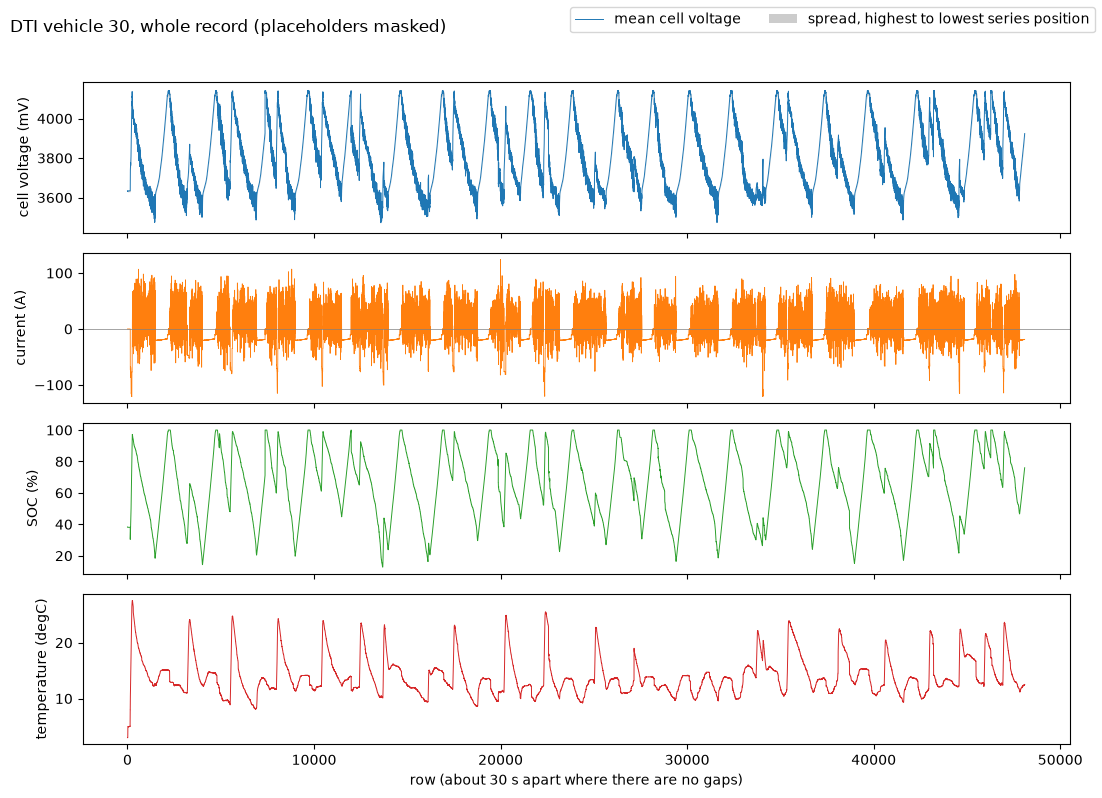

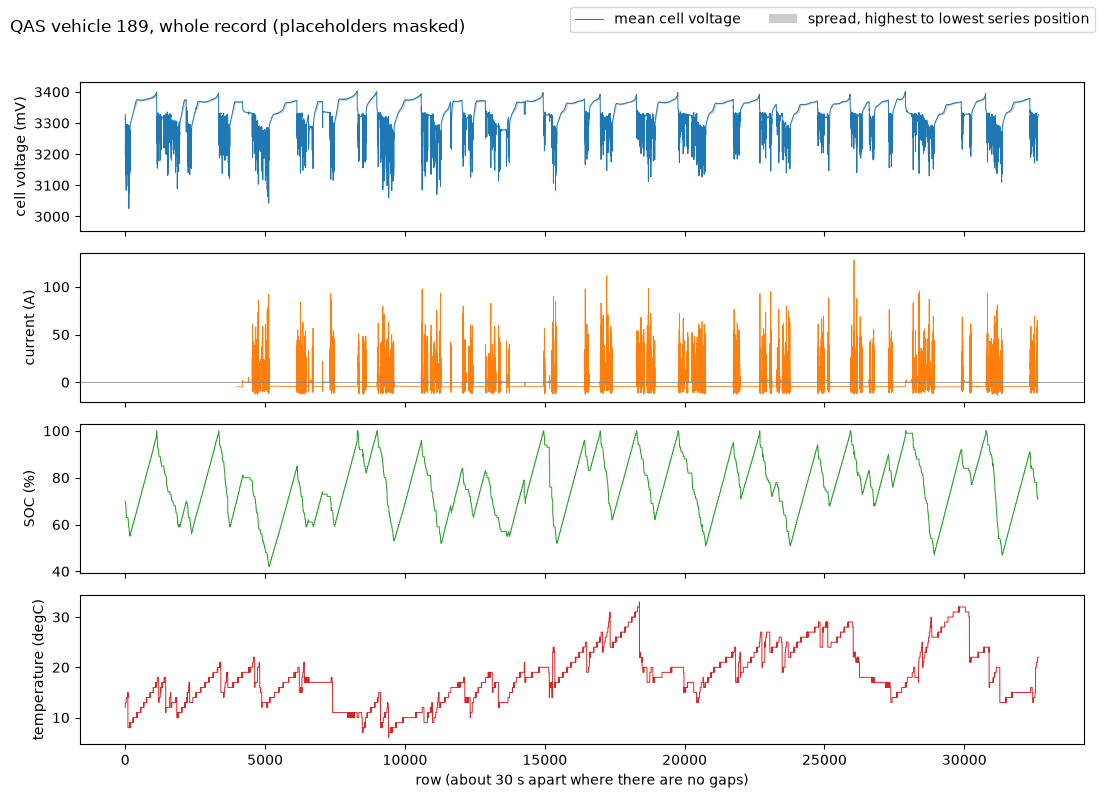

Zoomed window: QAS vehicle 189, rows 6,224 to 6,624, charge starting at row 6,474.


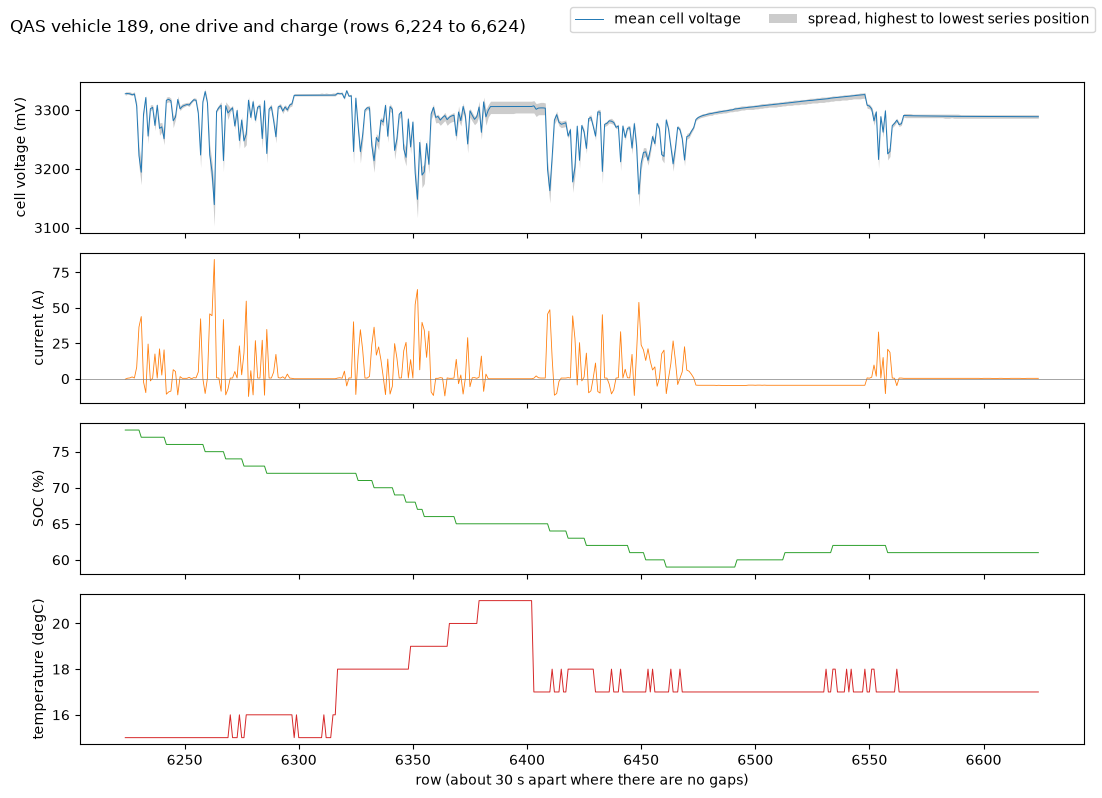

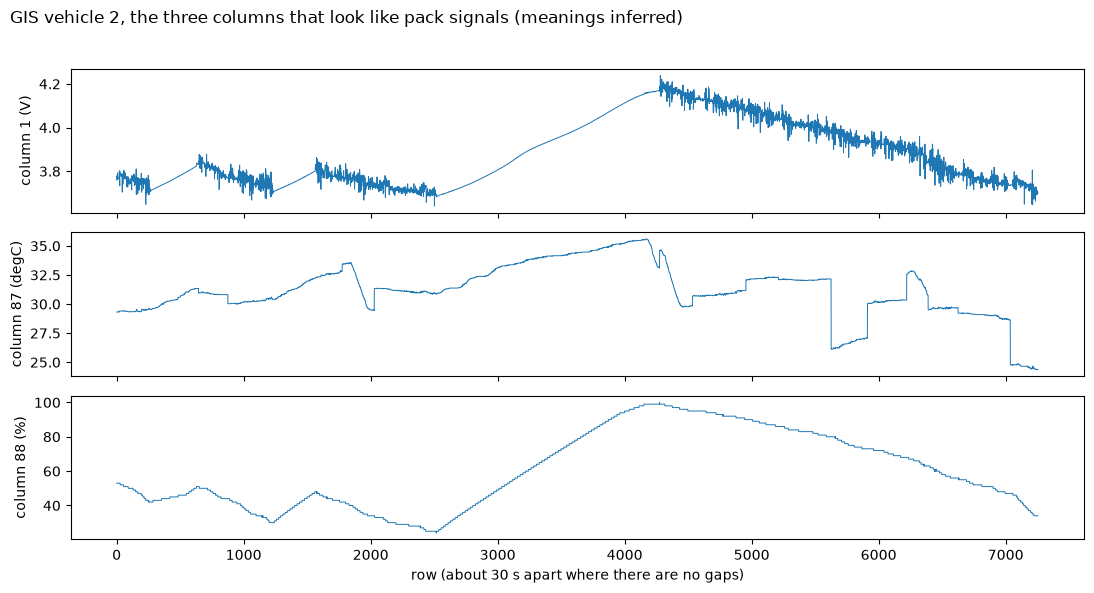

In [5]:
signals = {}
for brand in ['DTI', 'QAS']:
    f = load('cao', brand=brand, vehicle=examples.loc[brand, 'vehicle'], names='inferred', clean=True)
    cells = f[[c for c in f.columns if c.startswith('cell_v_')]] * (1.0 if brand == 'DTI' else 1000.0)  # mV
    signals[brand] = pd.DataFrame({'mean': cells.mean(axis=1), 'low': cells.min(axis=1), 'high': cells.max(axis=1),
                                   'current': f.current_A, 'soc': f.soc_pct, 'temperature': f.temperature_degC})

def plot_signals(data, title):
    figure, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
    band = axes[0].fill_between(data.index, data['low'], data['high'], color='0.8', linewidth=0)
    line, = axes[0].plot(data.index, data['mean'], color='C0', linewidth=0.7)
    axes[0].set_ylabel('cell voltage (mV)')
    axes[1].plot(data.index, data['current'], color='C1', linewidth=0.6)
    axes[1].axhline(0, color='0.5', linewidth=0.5)
    axes[1].set_ylabel('current (A)')
    axes[2].plot(data.index, data['soc'], color='C2', linewidth=0.7)
    axes[2].set_ylabel('SOC (%)')
    axes[3].plot(data.index, data['temperature'], color='C3', linewidth=0.7)
    axes[3].set_ylabel('temperature (degC)')
    axes[-1].set_xlabel('row (about 30 s apart where there are no gaps)')
    figure.legend([line, band], ['mean cell voltage', 'spread, highest to lowest series position'], loc='upper right', ncol=2)
    figure.suptitle(title, x=0.01, ha='left')
    figure.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

for brand in ['DTI', 'QAS']:
    plot_signals(signals[brand], f"{brand} vehicle {examples.loc[brand, 'vehicle']}, whole record (placeholders masked)")

# one drive-and-charge cycle: the first charge of at least 30 rows after row 4,000 with driving in the 200 rows before it
qas = signals['QAS']
charging = (qas['current'] < -2).astype(int)
runs = charging.groupby((charging != charging.shift()).cumsum()).transform('size')
starts = [i for i in qas.index[(charging == 1) & (charging.shift(fill_value=0) == 0) & (runs >= 30)] if i > 4000 and (qas['current'].loc[i - 200:i] > 5).sum() > 50]
start = starts[0]
window = qas.loc[start - 250:start + 150]
print(f'Zoomed window: QAS vehicle {examples.loc["QAS", "vehicle"]}, rows {window.index[0]:,} to {window.index[-1]:,}, charge starting at row {start:,}.')
plot_signals(window, f"QAS vehicle {examples.loc['QAS', 'vehicle']}, one drive and charge (rows {window.index[0]:,} to {window.index[-1]:,})")

gis_frame = frames['GIS']
figure, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for axis, (column, label) in zip(axes, [('col_01', 'column 1 (V)'), ('col_87', 'column 87 (degC)'), ('col_88', 'column 88 (%)')]):
    axis.plot(gis_frame.index, gis_frame[column], color='C0', linewidth=0.7)
    axis.set_ylabel(label)
axes[-1].set_xlabel('row (about 30 s apart where there are no gaps)')
figure.suptitle(f"GIS vehicle {examples.loc['GIS', 'vehicle']}, the three columns that look like pack signals (meanings inferred)", x=0.01, ha='left')
figure.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In DTI vehicle 30 the mean cell voltage cycles between about 3,470 and 4,140 mV, with current from -121 to 124 A, onboard state of charge from 13 to 100 percent and temperature from 3 to 28 degC. The spread across series positions (median 20 mV) is too thin to see at this scale. In QAS vehicle 189 the mean cell voltage cycles between about 3,030 and 3,400 mV and stays nearly flat near the top of each charge, as an LFP cell would. Its first 3,990 rows hold current near -1,000 A, a placeholder stretch that `clean=True` masks, so the current panel is empty there.

The zoomed window, rows 6,224 to 6,624 of the QAS example, shows driving (current pulses up to about 85 A, cell voltage dipping to about 3,140 mV, state of charge falling from 78 to 59 percent in 1-point steps), then a charge at about -5 A from row 6,474 during which voltage and state of charge rise, then a rest. The spread between the highest and lowest series position is a median 8 mV in the window and reaches 64 mV under the largest current pulses.

In GIS vehicle 2, column 1 moves between about 3.65 and 4.2 V and rises while column 88 climbs from 25 to 99, so column 88 behaves like a state of charge in percent and column 1 like a cell-sized voltage. Column 87 drifts between about 24 and 36, consistent with a temperature in degC. These meanings are inferred from the plots and ranges only.

## 5. Details

In-depth checks and sources. Open a heading below for the evidence.

### File layout in full

Each vehicle comes as three files (vin_1, vin_2, vin_3). This item shows what is in each, using one example vehicle per manufacturer. The authors model every cell as the pack state plus a per-cell deviation (paper Methods), and vin_2 and vin_3 hold both, for voltage and for state of charge. Each "cell" voltage is one series position, which may be several cells in parallel (Supplementary Note S1). As an inference from the voltage ranges, QAS cells sit at about 3.0 to 3.4 V, which looks like LFP, and DTI cells at about 3.5 to 4.2 V, which looks like NMC.

- **vin_1** holds seven normalized values per row for the authors' first network, which predicts the pack state one row ahead. Supplementary Note S2 lists the network's seven inputs as total voltage, current, vehicle speed, mileage, average temperature, onboard state of charge and vehicle operating status, but the release's vin_1 does not follow that list.

    Matched against vin_2, the columns are, in order:
    - temperature,
    - onboard state of charge,
    - a speed-like signal, DTI only and all zero in QAS,
    - likely total voltage,
    - current,
    - the Eq. 2 pack voltage (the paper's Eq. 2 pack voltage is a weighted average of the cell voltages, one cell's worth, not the total pack voltage) and
    - a pack-model state that vin_3 holds one row earlier.

    The last two are what the network predicts, one row ahead (Function_.py prepare_training_data), and the code also feeds their previous-row values back in as inputs. Neither mileage nor operating status is in the release.

- **vin_2** holds the measured cell voltages and most of the useful data.
    - For DTI and QAS each row has:
        - two values from the authors' pack model, both model outputs. The second behaves like the model's terminal voltage: the average cell voltage adjusted for the drop under current and for state of charge. The first is not identified. Then
        - one measured voltage per series position (85 for DTI, 110 for QAS), then 
        - one voltage deviation per series position (dU_i from the authors' deviation model, a model output, not a measurement),
        - then measured temperature, the state of charge reported by the vehicle's BMS (onboard estimate) and current. In the raw data DTI gives state of charge in percent and QAS as a fraction, and the loader converts both to percent.

    - GIS has a different layout and is of limited use. Its vin_2 has 90 columns, and the 85 where cell voltages would be all hold the same small number in each row (0 to about 0.075, varying by vehicle), so none are cell voltages. A few other columns look like a cell-sized voltage, temperature and state of charge. GIS has no labels, and neither the paper nor the authors' code (written for the QAS layout) says how GIS was used, so this notebook does not analyze it further.

- **vin_3** holds a state of charge for each series position, from the same model. Each row has:
    - two pack-model values, then
    - one state of charge per series position (the authors' model estimate: onboard SOC + per-cell offset), then
    - one state-of-charge deviation per series position (dSOC_i, with cell state of charge = onboard state of charge + deviation, exactly), then 
    - temperature, state of charge, an extra column and current. 
    
    For QAS the series positions differ by up to a few percent. For DTI every deviation is zero, so only QAS has per-cell state of charge. The extra column is 65535 (a placeholder) in QAS and, in DTI, the same speed-like signal as vin_1's third column.

The plot shows the median of every column of vin_2. Blocks of similar columns appear as flat stretches, which makes the layout visible at a glance.

,brand,example vehicle,vin_1 shape,vin_2 shape,vin_3 shape
0,DTI,30,"(48095, 1, 7)","(48095, 175)","(48095, 176)"
1,QAS,189,"(32649, 1, 7)","(32649, 225)","(32649, 226)"
2,GIS,2,"(7255, 1, 7)","(7255, 90)","(7255, 91)"


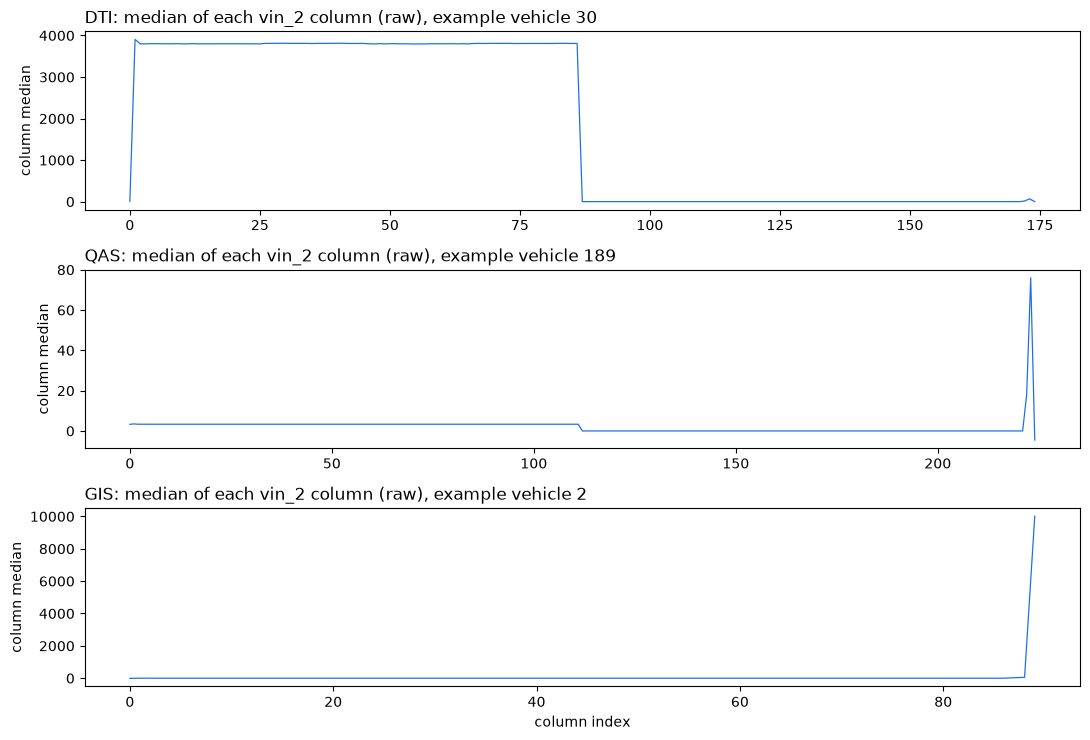

In [6]:
shape_rows = []
for brand in ['DTI', 'QAS', 'GIS']:
    vehicle = examples.loc[brand, 'vehicle']
    shapes = {which: tuple(load_raw(brand, vehicle, which).shape) for which in ['vin_1', 'vin_2', 'vin_3']}
    shape_rows.append({'brand': brand, 'example vehicle': vehicle, 'vin_1 shape': shapes['vin_1'], 'vin_2 shape': shapes['vin_2'], 'vin_3 shape': shapes['vin_3']})
display(pd.DataFrame(shape_rows))
figure, axes = plt.subplots(3, 1, figsize=(11, 7.5))
for axis, (brand, frame) in zip(axes, frames.items()):
    axis.plot(range(frame.shape[1]), frame.median().to_numpy(), linewidth=0.9, color='#1f6feb')
    axis.set_title(f'{brand}: median of each vin_2 column (raw), example vehicle {examples.loc[brand, "vehicle"]}', loc='left')
    axis.set_ylabel('column median')
axes[-1].set_xlabel('column index')
figure.tight_layout()
plt.show()

The example vehicles, nearest each brand's median record length, are DTI 30 (48,095 rows), QAS 189 (32,649 rows) and GIS 2 (7,255 rows). In each, vin_1 has shape rows x 1 x 7, and vin_3 has one column more than vin_2. The median plot shows the 2/N/N/3 layout for DTI and QAS: a flat stretch near 3,800 over DTI's cell columns 2 to 86 and near 3.3 over QAS's cell columns 2 to 111, with the second leading column at a similar level, then a flat stretch near zero for the deviation block, then a few distinct trailing values. The columns mix units (mV or V, percent, A, degC), so only the shape of each curve is meaningful. The GIS plot stays near zero until a jump in its last columns.

There is no timestamp in any of the files. The authors state that rows are 30 s apart, and describe removing rows with missing or out-of-range values and replacing suspected sensor faults in a cell's reading with the median of all cells (Supplementary Note S5). The released files do not appear to have passed all of that: they still hold placeholder codes (386,281 in QAS), stretches of rows at about -1,000 A, among them the first 3,990 rows of the QAS example, zero cell voltages and model-output values near -5e12 (counted under Placeholder values below). Neighboring rows may still be further apart than 30 s where rows were removed, and the release does not mark which cell values, if any, were filled in.

### Where these meanings come from

The authors model every cell as the pack state plus a deviation state. The paper's Methods put it as "the cell state is the sum of the pack state and the deviation state", with equivalent-circuit pack and deviation models solved by a strong-tracking Kalman filter. Supplementary Fig. S4 shows the deviation model with dU_i, dOCV_i, dSOC_i and dR_i, and Supplementary Fig. S5 names voltage deviation and SOC deviation as intermediate variables. The released `Function_.py` holds the formulas (`DUi = OCVi - OCV - I*DRi` and `Xi = soc + xi`). Those functions are never called in the released scripts, and the script that made vin_2 and vin_3 is not released. The paper's Eq. 3 defines the voltage deviation as each cell's voltage minus the Eq. 2 pack voltage, but the released block is not that difference. It is the filtered deviation-model output, and it cannot be recomputed because the model's parameters are not released. The code gives every cell the same resistance offset (`DRi = 3e-6`), so the voltage deviations can differ between cells only through their state-of-charge deviations, on a flat OCV curve. That is why they are nearly the same for every cell in a row.

The paper's Methods call the Eq. 2 quantity the "pack model terminal voltage U_T,p", which this notebook calls the Eq. 2 pack voltage. The authors' code fixes where each block starts and ends, but never names the blocks. The first of vin_3's two pack-model values equals vin_1's last column one row later (Checks against the authors' code).

### Checks against the authors' code

In [7]:
display(pd.DataFrame(fleet_rows))
display(pd.DataFrame(leading_rows))
display(pd.DataFrame(identity_rows))
identity_checks = pd.DataFrame([dict(zip(['holds', 'best aggregate', 'median absolute error', 'error for a block of zeros'], identity_holds(brand)), brand=brand) for brand in ['DTI', 'QAS']])
display(identity_checks[['brand', 'best aggregate', 'median absolute error', 'error for a block of zeros', 'holds']])
display(sign_table)
display(gis_table)

,brand,block,fleet minimum,fleet median of per-vehicle medians,fleet maximum
0,DTI,leading,0.000000e+00,1962.594001,4468.549300
1,DTI,cells,0.000000e+00,3816.500000,4166.000000
2,DTI,deviations,0.000000e+00,0.099998,0.100516
3,DTI,trailing,-1.720000e+02,25.937500,336.700000
4,GIS,leading,-1.462053e+01,-3.617220,4.434763
5,GIS,cells,NaN,NaN,NaN
6,GIS,deviations,NaN,NaN,NaN
7,GIS,trailing,0.000000e+00,0.069928,13513.000000
8,QAS,leading,-2.649224e+12,3.423306,4.800731
9,QAS,cells,0.000000e+00,3.329000,3.649000


,brand,leading column,candidate,correlation,mean absolute difference
0,DTI,0,row mean,-0.005752,3815.289920
1,DTI,0,row median,-0.005761,3815.282405
2,DTI,0,row min,-0.005495,3804.509414
3,DTI,0,row max,-0.006037,3823.800379
4,DTI,0,row sum,-0.005752,324742.036911
5,DTI,1,row mean,0.980066,114.750138
6,DTI,1,row median,0.980175,114.772029
7,DTI,1,row min,0.978685,125.319415
8,DTI,1,row max,0.981031,106.474775
9,DTI,1,row sum,0.980066,320812.610977


,brand,candidate identity,valid rows,median absolute error,max absolute error
0,DTI,cell_i - row mean,48095,4.417533,62.229399
1,DTI,cell_i - row median,48095,4.100054,88.099954
2,DTI,cell_i - row min,48095,8.900008,108.900012
3,DTI,cell_i - row max,48095,7.099998,109.099988
4,DTI,cell_i - row sum,48095,319616.100059,347907.100000
5,QAS,cell_i - row mean,32649,0.000839,69.444026
6,QAS,cell_i - row median,32649,0.000991,69.444271
7,QAS,cell_i - row min,32649,0.002989,69.450271
8,QAS,cell_i - row max,32649,0.003045,69.439271
9,QAS,cell_i - row sum,32649,363.628958,370.875929


,brand,best aggregate,median absolute error,error for a block of zeros,holds
0,DTI,row median,4.100054,4.000000,False
1,QAS,row mean,0.000839,0.000909,False


,"mean SOC change, positive current","mean SOC change, negative current",sign convention
0,-0.064498,0.027104,positive current is discharge


,GIS vehicles,small columns tested,constant within every vehicle,vary between vehicles,identical within each row,maximum absolute correlation with counter
0,41,85,False,True,True,0.960797


In [8]:
vin3 = pd.read_csv(ROOT / 'reports' / 'checks' / 'cao_vin3_soc_per_vehicle.csv', dtype={'vehicle': str})
vin3_summary = vin3.groupby('brand').apply(lambda g: pd.Series({
    'vehicles': len(g),
    'cell SOC = onboard SOC + dSOC holds (99th percentile error at most 0.0012, raw units)': int((g.offset_error_p99 <= 0.0012).sum()),
    'cell mean matches pack SOC (correlation >= 0.99, ratio within 1 percent)': int(((g.mean_soc_corr >= 0.99) & ((g.mean_soc_median_ratio - 1).abs() <= 0.01)).sum()),
    'per-cell SOC spread, percentage points (median row standard deviation)': round(float(g.cell_soc_row_std_median.median()) * (100 if g.name == 'QAS' else 1), 2),
    'trailing columns copied from vin_2': int(g.trailing_copies_vin2.sum()),
    'extra trailing column (raw)': f'{g.extra_min.min():g} to {g.extra_max.max():g}',
    'vin_2 voltage deviation spread across series positions, V for QAS and mV (assumed) for DTI (median row standard deviation)': float(f'{g.dev2_row_std_median.median():.2g}'),
    'vin_2 voltage deviation vs cell minus row mean (median correlation)': round(float(g.dev2_corr_with_cell_minus_mean.median()), 3),
    'per-cell part of voltage deviation vs per-cell part of SOC deviation (median correlation)': round(float(g.dev2_vs_dsoc_corr.median()), 2),
    'same, range across vehicles': f'{g.dev2_vs_dsoc_corr.min():.3f} to {g.dev2_vs_dsoc_corr.max():.3f}',
}), include_groups=False)
with pd.option_context('display.max_colwidth', None):
    display(vin3_summary.T)
print('From scripts/checks/cao_vin3_soc.py, run over every DTI and QAS vehicle through the loader, rows with placeholder values left out.')

brand,DTI,QAS
vehicles,80,393
"cell SOC = onboard SOC + dSOC holds (99th percentile error at most 0.0012, raw units)",74,393
"cell mean matches pack SOC (correlation >= 0.99, ratio within 1 percent)",73,359
"per-cell SOC spread, percentage points (median row standard deviation)",0.0,0.55
trailing columns copied from vin_2,80,393
extra trailing column (raw),0 to 2223,65535 to 65535
"vin_2 voltage deviation spread across series positions, V for QAS and mV (assumed) for DTI (median row standard deviation)",0.0,0.0003
vin_2 voltage deviation vs cell minus row mean (median correlation),-0.0,0.041
per-cell part of voltage deviation vs per-cell part of SOC deviation (median correlation),-0.0,0.29
"same, range across vehicles",-0.000 to 0.000,0.003 to 0.957


From scripts/checks/cao_vin3_soc.py, run over every DTI and QAS vehicle through the loader, rows with placeholder values left out.


In [9]:
regen = pd.read_csv(ROOT / 'reports' / 'checks' / 'cao_regenerate_per_vehicle.csv', dtype={'vehicle': str}, keep_default_na=False)
def entries(group, column, key):
    return [json.loads(x)[key] for x in group[column] if x]
regen_rows = {}
for brand, group in regen.groupby('brand'):
    lead = entries(group, 'leading', 'vin_2 col 1')
    v1 = [json.loads(x) for x in group.vin1 if x]
    matched = lambda j, name: sum(e[str(j)]['best'] == name for e in v1)
    row = {'vehicles': len(group),
           'vin_2 column 1, joint fit on pack voltage, current and SOC (median R^2)': round(float(np.nanmedian([e['joint_modepi_current_soc_r2'] for e in lead])), 3),
           'vin_1 column 0 is temperature': matched(0, 'temperature'), 'vin_1 column 1 is state of charge': matched(1, 'pack SOC'),
           'vin_1 column 2 is all zero': sum(e['2']['best'] == 'constant' for e in v1), 'vin_1 column 3 best matches the cell-voltage sum': matched(3, 'cell sum'),
           'vin_1 column 4 is current': matched(4, 'current'),
           'vin_1 column 5 is volt_modepi': matched(5, 'volt_modepi'), "vin_1 column 6 is vin_3's column 0 one row later": matched(6, 'vin_3 col 0 (next row)'),
           'dU vs dSOC within rows (median correlation)': round(float(pd.to_numeric(group.dU_rowcorr_median, errors='coerce').median()), 3),
           'dU regenerated with a fitted OCV curve (median within-row correlation)': round(float(pd.to_numeric(group.dU_regen_rowcorr_median, errors='coerce').median()), 3),
           'dU regenerated: median absolute error': float(f"{pd.to_numeric(group.dU_regen_abs_error_median, errors='coerce').median():.2g}"),
           'median |dU|': float(f"{pd.to_numeric(group.dU_abs_median, errors='coerce').median():.2g}")}
    if brand == 'DTI':
        extra = [json.loads(x) for x in group.extra if x]
        row['extra column is vin_1 column 2 (|r| = 1)'] = sum(bool(e['best']) and e['best'][0][0] == 'vin_1 col 2' and e['best'][0][1] >= 0.999 for e in extra)
        row['extra column at zero: rest / discharging / charging (median share)'] = ' / '.join(f"{np.median([e[k] for e in extra if e[k] is not None]):.3f}" for k in ['zero_share_rest', 'zero_share_discharging', 'zero_share_charging'])
    regen_rows[brand] = row
with pd.option_context('display.max_colwidth', None):
    display(pd.DataFrame(regen_rows).map(lambda v: '' if v is None or (isinstance(v, float) and np.isnan(v)) else (f'{v:g}' if isinstance(v, (int, float, np.integer, np.floating)) else v)))
print('From scripts/checks/cao_regenerate.py, run over every DTI and QAS vehicle through the loader, rows with placeholder values left out.')

,DTI,QAS
vehicles,80,393
"vin_2 column 1, joint fit on pack voltage, current and SOC (median R^2)",0.997,0.998
vin_1 column 0 is temperature,79,393
vin_1 column 1 is state of charge,79,393
vin_1 column 2 is all zero,1,393
vin_1 column 3 best matches the cell-voltage sum,45,337
vin_1 column 4 is current,79,393
vin_1 column 5 is volt_modepi,79,393
vin_1 column 6 is vin_3's column 0 one row later,79,372
dU vs dSOC within rows (median correlation),,0.946


From scripts/checks/cao_regenerate.py, run over every DTI and QAS vehicle through the loader, rows with placeholder values left out.


In [10]:
first_row = pd.read_csv(ROOT / 'reports' / 'checks' / 'cao_vin3_first_row.csv', dtype={'vehicle': str})
first_row_summary = first_row.groupby('brand').apply(lambda g: pd.Series({
    'vehicles': len(g),
    'first row at 1/100 of the onboard SOC': int(np.isclose(g.first_row_ratio, 0.01, rtol=0.05).sum()),
    'per-cell SOC without the first row, percent': f'{g.min_without_first_row.min():.4g} to {g.max_without_first_row.max():.4g}',
}), include_groups=False)
display(first_row_summary)
print('From scripts/checks/cao_vin3_first_row.py, every DTI and QAS vehicle through the loader.')

,vehicles,first row at 1/100 of the onboard SOC,"per-cell SOC without the first row, percent"
brand,,,
DTI,80,80,-5.827e-50 to 100
QAS,393,393,-36.86 to 225.5


From scripts/checks/cao_vin3_first_row.py, every DTI and QAS vehicle through the loader.


In [11]:
quality = pd.read_csv(ROOT / 'reports' / 'checks' / 'cao_release_quality.csv', dtype={'vehicle': str})
gap = quality[quality.brand == 'DTI'].dti_col1_minus_max_cell_median
display(pd.DataFrame([{'DTI vehicles': len(gap), 'vin_2 column 1 minus the highest cell, median per vehicle (mV): 10th percentile': round(gap.quantile(0.1)),
                       'median': round(gap.median()), '90th percentile': round(gap.quantile(0.9))}]))
print('From scripts/checks/cao_release_quality.py, every DTI vehicle, rows without placeholder values or zero cells.')

,DTI vehicles,"vin_2 column 1 minus the highest cell, median per vehicle (mV): 10th percentile",median,90th percentile
0,80,37,95,126


From scripts/checks/cao_release_quality.py, every DTI vehicle, rows without placeholder values or zero cells.


The tables above are the evidence for the column map, one line per check:

- **Cell block, by its range.** DTI cell values sit around 3,816 (up to 4,166) and QAS around 3.33 (up to 3.65), so DTI cell voltages are in millivolts and QAS in volts.
- **Deviation block, by its range.** Small for both brands (about 0.1 for DTI, near zero for QAS), apart from numerical blow-ups of the authors' filter down to -5.1e12 in QAS (counted under Placeholder values).
- **Leading columns.** The second one moves with the average cell voltage (correlation 0.98 for DTI, 0.66 for QAS). The first one does not.
- **Sign of the current.** State of charge falls when current is positive and rises when it is negative, so positive current means discharge.
- **GIS.** In all 41 GIS vehicles, the 85 small columns hold one repeated value per row, different from vehicle to vehicle.
- **Cell state of charge = onboard state of charge + dSOC_i.** Holds in all 393 QAS and 74 of 80 DTI vehicles. The cell average matches the onboard value in 359 QAS and 73 DTI vehicles.
- **Per-cell state of charge.** Series positions differ within a row in QAS (median row standard deviation 0.55 percentage points) and not in DTI (0).
- **Trailing columns.** Three of the four vin_3 trailing columns copy vin_2 in every vehicle. The extra one is always 65535 in QAS and runs from 0 to 2,223 in DTI.
- **Voltage deviations across series positions.** Nearly the same in every position of a row: median row standard deviation 0.0003 V in QAS and 0 in DTI (DTI in mV, a unit assumed from the cell block). They do not follow each position's distance from the row mean (median correlation 0.041 in QAS).
- **Voltage deviation against state-of-charge deviation.** In QAS their per-position parts correlate at a median of 0.29 over whole records (0.003 to 0.957 across vehicles) and 0.946 within rows. In DTI both are constant across positions.
- **vin_2's second pack-model column.** An affine function of the Eq. 2 pack voltage, current and onboard state of charge reproduces it (median R^2 0.997 for DTI, 0.998 for QAS), consistent with a model terminal voltage. In DTI it sits above the highest cell, by a median of 95 mV across vehicles (37 to 126 mV from the 10th to the 90th percentile, table below).
- **vin_1.** Column 0 is temperature and column 1 the state of charge (79 of 80 DTI and all 393 QAS vehicles). Column 4 is current and column 5 the Eq. 2 pack voltage (79 and 393). Column 6 is vin_3's first column one row later (79 and 372). Column 3 best matches the sum of the cell voltages (45 of 80 DTI and 337 of 393 QAS vehicles), so it is likely total voltage. Column 2 is all zero in all 393 QAS vehicles.
- **DTI extra column.** It equals vin_1's column 2 (79 of 80 vehicles) and is zero in a median 85.9 percent of rows at rest, 0.7 percent while discharging and 75.0 percent while charging. That fits vehicle speed, with two caveats: its maximum of 2,223 makes the unit doubtful (no vehicle reaches 2,223 km/h, and 0.1 km/h would mean 222 km/h), and it is non-zero in about a quarter of charging rows.
- **dU regenerated with a fitted OCV curve.** In QAS the pattern across positions comes back (median within-row correlation 0.885) but not the size (median absolute error 0.00048 against a median |dU| of 0.00014). In DTI the constant 0.1 is not reproduced (error 0.1). Without the authors' parameters dU cannot be recomputed.

**First row of vin_3.** In all 80 DTI and all 393 QAS vehicles the first row holds each position's state of charge at 1/100 of the onboard state of charge (for example 0.383 where the onboard value is 38.3). Function_.py's solvers() starts the filter this way (SOC[0] = 0.01 * soc[0], every cell set to it), so it is the filter's start-up row, not a measurement. It is also why six very short DTI records (4 to 74 rows) fail the cell = onboard + dSOC_i test above: one start-up row is more than 1 percent of their rows. Without the first row the per-position state of charge runs from about 0 to 100 percent in DTI and from -36.86 to 225.5 percent in QAS, raw data, the QAS extremes coming from a few vehicles.

### Gaps in the record

In [12]:
jump_rows = []
for brand in ['DTI', 'QAS']:
    data = signals[brand]
    soc_step = data['soc'].diff().abs()
    voltage_step = data['mean'].diff().abs()
    at_jumps = voltage_step[soc_step > 3]
    typical = voltage_step.quantile(0.99)
    jump_rows.append({'brand': brand, 'vehicle': examples.loc[brand, 'vehicle'], 'rows': len(data),
                      'SOC jumps over 3 percentage points': int((soc_step > 3).sum()),
                      'mean cell voltage step at those rows, median (mV)': round(float(at_jumps.median()), 1),
                      'mean cell voltage step, 99th percentile of all rows (mV)': round(float(typical), 1),
                      'jumps where the voltage step exceeds that': int((at_jumps > typical).sum())})
display(pd.DataFrame(jump_rows))

,brand,vehicle,rows,SOC jumps over 3 percentage points,"mean cell voltage step at those rows, median (mV)","mean cell voltage step, 99th percentile of all rows (mV)",jumps where the voltage step exceeds that
0,DTI,30,48095,20,58.7,66.8,9
1,QAS,189,32649,8,20.0,103.6,1


The onboard state of charge jumps by more than 3 percentage points between neighboring rows 20 times in DTI vehicle 30 (48,095 rows) and 8 times in QAS vehicle 189 (32,649 rows), placeholder values masked. These are likely gaps in the record or BMS SOC resets. In DTI, 9 of the 20 jumps come with a step in the mean cell voltage larger than 99 percent of all row-to-row steps (median 58.7 mV at the jumps against a 99th percentile of 66.8 mV), which fits gaps during which the pack was driven or charged. In QAS only 1 of the 8 does (median 20.0 mV against 103.6 mV), so most of its jumps have no matching voltage change and may be BMS resets. A gap while the vehicle is parked changes neither signal, so these counts undercount the gaps.

### Placeholder values

In [13]:
from fielddata.loaders.cao import _SENTINEL_VALUES

quality = pd.read_csv(ROOT / 'reports' / 'checks' / 'cao_release_quality.csv', dtype={'vehicle': str})
left = quality.groupby('brand').apply(lambda g: pd.Series({
    'vehicles': len(g),
    'placeholder code values (vehicles)': f"{int(g.placeholder_values.sum()):,} ({int((g.placeholder_values > 0).sum())})",
    'rows at or below -900 A (vehicles)': f"{int(g.current_rows_at_or_below_minus_900.sum()):,} ({int((g.current_rows_at_or_below_minus_900 > 0).sum())})",
    'zero cell voltages: values / rows (vehicles)': f"{int(g.zero_cell_values.sum()):,} / {int(g.zero_cell_rows.sum()):,} ({int((g.zero_cell_rows > 0).sum())})",
    'filter blow-ups beyond 1e6: rows (vehicles)': f"{int(g.blowup_rows.sum()):,} ({int((g.blowup_rows > 0).sum())})",
    'blow-up values in vin_2 / vin_3': f"{int(g.blowup_values_vin2.sum()):,} / {int(g.blowup_values_vin3.sum()):,}",
    'lowest blow-up value': f"{g.blowup_min.min():.3g}" if g.blowup_min.notna().any() else 'none',
    'blow-ups starting in the first row': int((g.blowup_first_row == 0).sum()),
}), include_groups=False)
with pd.option_context('display.max_colwidth', None):
    display(left.T)
print('From scripts/checks/cao_release_quality.py, every DTI and QAS vehicle, values as released.')

vehicle = examples.loc['QAS', 'vehicle']
raw = load('cao', brand='QAS', vehicle=vehicle, names='inferred')
cleaned = load('cao', brand='QAS', vehicle=vehicle, names='inferred', clean=True)
codes = int(np.isin(raw.current_A.to_numpy(), _SENTINEL_VALUES).sum())
stretch = raw.index[raw.current_A <= -900]
du = raw[[c for c in raw.columns if c.startswith('cell_dU_')]]
low_row = int(du.min(axis=1).idxmin())
masked_columns = sorted(raw.columns[(raw.notna() & cleaned[raw.columns].isna()).any()])
print(f"QAS vehicle {vehicle}: {codes:,} exact codes in current_A and {len(stretch):,} rows at or below -900 A, between rows {stretch.min():,} and {stretch.max():,}. "
      f"Lowest voltage deviation {du.min().min():.2f} in row {low_row}. clean=True masks {cleaned.attrs['masked_value_count']:,} values, all in {', '.join(masked_columns)}, flags {int(cleaned.current_invalid.sum()):,} rows in current_invalid, and keeps all {len(cleaned):,} rows.")

brand,DTI,QAS
vehicles,80,393
placeholder code values (vehicles),0 (0),"386,281 (352)"
rows at or below -900 A (vehicles),0 (0),"1,775,068 (352)"
zero cell voltages: values / rows (vehicles),4 / 1 (1),433 / 335 (5)
filter blow-ups beyond 1e6: rows (vehicles),0 (0),546 (90)
blow-up values in vin_2 / vin_3,0 / 0,"9,061 / 0"
lowest blow-up value,none,-5.09e+12
blow-ups starting in the first row,0,0


From scripts/checks/cao_release_quality.py, every DTI and QAS vehicle, values as released.


QAS vehicle 189: 795 exact codes in current_A and 3,990 rows at or below -900 A, between rows 0 and 3,989. Lowest voltage deviation -69.44 in row 7. clean=True masks 3,990 values, all in current_A, flags 3,990 rows in current_invalid, and keeps all 32,649 rows.


QAS writes placeholder codes where a reading is missing, for example -1,000 in the current column. They look like real values unless they are masked, and one placeholder in a current sum or a mean is enough to spoil it. The table counts, for every DTI and QAS vehicle, raw data, what the cleaning in Supplementary Note S5 would be expected to remove.

QAS still holds 386,281 exact placeholder codes (-1,000, -999, -1,004.8 and 65,535) in 352 of its 393 vehicles, and 1,775,068 rows (12.4 percent of QAS rows) with current at or below -900 A in the same 352 vehicles, a stretch of values near -1,000 A where no current was recorded. No QAS current falls between -900 and -200 A, and real charging reaches at most -86.7 A. Zero cell voltages occur in 335 rows of 5 QAS vehicles (433 values) and in one row of one DTI vehicle (4 values). The authors' filter outputs in vin_2 (the two pack-model columns and the voltage deviations) hold numerical blow-ups, values beyond 1e6 down to -5.09e12, in 546 rows of 90 QAS vehicles (9,061 values), never in a first row and never in vin_3. DTI has no codes, no -1,000 A rows and no blow-ups.

In the QAS example vehicle 189 there are 795 exact codes in the current column and 3,990 rows at or below -900 A, between rows 0 and 3,989. Its lowest voltage deviation, -69.44, is in row 7, inside that stretch: the deviation jumps from near zero to -69.44 there and decays over the next rows (-8.2, -3.5, -1.8 and so on), a transient of the authors' filter, not a cell reading. `clean=True` masks 3,990 values in this vehicle, all in `current_A`: every QAS current at or below -900 A, which takes in the exact codes. It marks those rows in the boolean column `current_invalid` and keeps all 32,649 rows. The authors' model outputs in flagged rows were computed from the bad current and are suspect. Across the fleet `clean=True` also masks the blow-ups (values beyond 1e6) and zero cell voltages.

### Paper cross-check

In [14]:
facts = json.loads((ROOT / 'reports' / 'facts' / 'cao.json').read_text(encoding='utf-8'))['facts']
energy_cache = pd.read_csv(ROOT / 'reports' / 'facts' / '_cache' / 'cao_energy_per_vehicle.csv', dtype={'vehicle': str})
counts = all_systems.brand.value_counts()
faulty = all_systems[all_systems.label == 1].brand.value_counts()
widths = profiles.groupby('brand').width.unique()
assert all(len(widths[brand]) == 1 for brand in ['DTI', 'QAS'])
channels = {brand: (int(widths[brand][0]) - 5) // 2 for brand in ['DTI', 'QAS']}
cells = sum(int(counts[brand]) * channels[brand] for brand in ['DTI', 'QAS'])
hours = row_counts.n_rows.sum() * 30 / 3600
energy = sum(energy_cache[energy_cache.brand == brand].kwh.median() * counts[brand] for brand in ['DTI', 'QAS']) / 1000
cross = pd.DataFrame([
    ('vehicles', '515 (p. 1)', f'{len(all_systems)}', f"{facts['units_released']['value']}"),
    ('DTI / QAS / GIS vehicles', 'not stated', f"{counts['DTI']} / {counts['QAS']} / {counts['GIS']}", ''),
    ('faulty vehicles, label 1, DTI / QAS', 'not stated', f"{faulty.get('DTI', 0)} / {faulty.get('QAS', 0)}", ''),
    ('frame spacing', '30 s (Supplementary Note S5, p. 24)', 'not measurable: no timestamps', ''),
    (f"cell voltage channels, series positions (DTI x {channels['DTI']}, QAS x {channels['QAS']}, GIS excluded)", 'not stated', f'{cells:,}', f"{facts['cells_liion']['value']:,}"),
    ('observation hours (all rows x the stated 30 s)', 'not stated', f'{hours:,.0f}', f"{facts['obs_hours']['value']:,.0f}"),
    ('estimated fleet pack capacity, MWh', 'not stated', f'{energy:.2f}', f"{facts['energy_mwh']['value']}"),
], columns=['quantity', 'paper', 'this notebook', 'facts table'])
display(cross)

,quantity,paper,this notebook,facts table
0,vehicles,515 (p. 1),514,514
1,DTI / QAS / GIS vehicles,not stated,80 / 393 / 41,
2,"faulty vehicles, label 1, DTI / QAS",not stated,3 / 58,
3,frame spacing,"30 s (Supplementary Note S5, p. 24)",not measurable: no timestamps,
4,"cell voltage channels, series positions (DTI x...",not stated,"50,030","50,030"
5,observation hours (all rows x the stated 30 s),not stated,"151,900","151,900"
6,"estimated fleet pack capacity, MWh",not stated,15.11,15.107


The table puts each number the paper states next to the number measured here.

The paper states 515 vehicles and the release holds 514, one fewer. The release splits them into 80 DTI, 393 QAS and 41 GIS vehicles, a split the paper does not state. The paper does not state per-brand faulty counts. The release labels 3 DTI and 58 QAS vehicles as faulty. The 30 s frame spacing cannot be checked, because the files have no timestamps. The cell-voltage channel count (50,030), observation hours (151,900, based on the stated 30 s spacing) and estimated fleet pack capacity (15.107 MWh) are this collection's own figures, used in the descriptor's tables. The paper does not state them. The capacity is not energy throughput: each vehicle's capacity comes from the charge passed over large state-of-charge swings at the stated 30 s spacing, times its mean pack voltage, and the fleet figure is the median per brand times the vehicles in that brand.

## 6. Example uses and limits

**DTI and QAS (473 vehicles)** have a voltage for every series position in every row (85 and 110 positions), plus pack-level temperature, state of charge and current. A few examples of what this allows:
- cell-to-cell spread and weakest-cell tracking, the core of most field fault detection,
- spotting a cell that drifts away from its neighbors over a record,
- benchmarking fault detection: 61 vehicles labeled faulty against 412 labeled healthy,
- cell imbalance from per-cell state-of-charge estimates, for QAS only. These are an output of the authors' model (vin_3), not measurements. DTI has none, because its cell state-of-charge deviations are all zero.

**Limits:**
- No timestamps, only the authors' stated 30 s spacing, so no calendar aging, seasonality or true durations.
- Labels are per vehicle and only faulty or healthy, with no fault type, no faulty cell and no onset time. The paper's four fault types (TR, EL, ISC, EA) cannot be recovered from the release.
- About 12% of QAS rows (1,775,068 of 14.3 million, in 352 of 393 vehicles) have no valid current. `clean=True` masks it, and `current_invalid` marks the rows. The authors' model outputs in those rows were computed from the bad current and are suspect.
- One temperature value per row, so no temperature differences across the pack.
- The authors' processing replaced cell readings that looked like sensor faults with the median of all cells (Supplementary Note S5). If the release went through that step, some single-cell faults may be hidden, and the release does not mark which readings were replaced.

**GIS (41 vehicles)** has no cell-level data, no labels and no timestamps, so it supports little beyond coarse statistics such as state-of-charge and temperature ranges.